# Local-exact complex-Taylor far-field approximation

A direct point-mass ray trace sums every star for every query. The accelerated
path instead partitions the lens plane into regular cells. Stars near the
query cell are still evaluated exactly. The smooth contribution of all more
distant stars is represented by a short complex Taylor polynomial.

This notebook explains every `FarFieldApproxConfig` hyperparameter, reproduces the
Q2237 image-B method schematic, and measures source-plane coordinate error
against a direct all-star ray trace. The approximation changes only how the
lens equation is evaluated. It is independent of the IPM scout parameters
$N$, $k$, $r$, and $v$.

In [1]:
from dataclasses import replace
from pathlib import Path
from time import perf_counter
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import microcaustics as mc
import microcaustics.plotting as mcp
from microcaustics.solvers import TaylorFarFieldApproximation

plt.rcParams.update(mcp.publication_style())
OUTPUT_DIRECTORY = Path("far_field_output")
OUTPUT_DIRECTORY.mkdir(exist_ok=True)
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available and capabilities.triton_importable
runtime_config = mc.RuntimeConfig(
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda else "torch-eager",
    dtype=torch.float32,
    strict_backend=use_cuda,
)
print(mcp.runtime_description())

Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0


## What is approximated

For a distant point mass, the deflection is analytic in
$\overline{z}$. Around a node $z_0$ it can therefore be expanded as

\[
\frac{m_j}{\overline{z}-\overline{z}_j}
=\frac{m_j}{\overline{z}_0-\overline{z}_j}
\sum_{n=0}^{p}
\left(-\frac{\Delta\overline{z}}
{\overline{z}_0-\overline{z}_j}\right)^n.
\]

The package sums nearby stars exactly and accumulates the coefficients of this
series for the remaining stars. Within a parent cell, a query selects the
nearest node on a uniform lattice and evaluates one polynomial at the exact
query position. It does not blend four nodes. This avoids four coefficient
reads and four polynomial evaluations, and it keeps the analytic Jacobian
consistent with the deflection.

The implementation is a regular local-exact/far-field partition, not a
hierarchical tree walk. Every dynamic epoch receives its own coefficients.
The production scheduler does not interpolate far-field states in time.

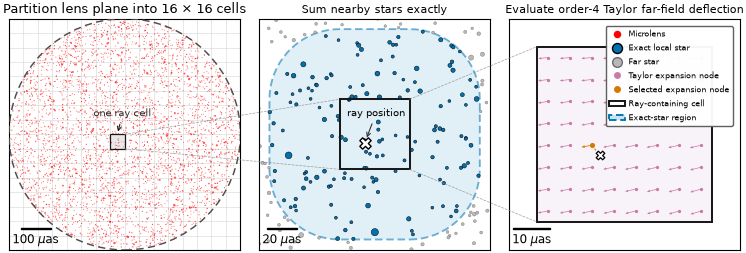

In [2]:
def locate_package_root():
    candidates = (Path(mcp.__file__).resolve().parents[3], Path.cwd(), *Path.cwd().parents)
    return next(
        path for path in candidates
        if (path / "examples" / "data" / "q2237b_method_figures").is_dir()
    )

fixture_directory = locate_package_root() / "examples" / "data" / "q2237b_method_figures"
with np.load(fixture_directory / "paper_far_field_schematic_data.npz", allow_pickle=False) as fixture:
    star_x = torch.as_tensor(fixture["star_x_uas"], dtype=torch.float64)
    star_y = torch.as_tensor(fixture["star_y_uas"], dtype=torch.float64)
    star_mass = torch.as_tensor(fixture["star_mass"], dtype=torch.float64)

distances = mc.LensingDistances.from_redshifts(0.0395, 1.695)
stars = mc.PointMassField.from_masses(star_x, star_y, star_mass, distances)
macro = mc.MacroLens(
        convergence=0.391,
        shear=0.391,
        shear_angle_deg=141.73,
)
lens_region = mc.PlaneRegion((754.11, 754.11))
system = mc.MicrolensingSystem(
    macro=macro, distances=distances, stars=stars,
    source_grid=mc.PlaneGrid((64, 64), (9.3819, 9.3819)),
    lens_region=lens_region, runtime=runtime_config,
)
simulation = system.realize().simulation  # method schematic uses the resolved tracer
production_far_field = mc.FarFieldApproxConfig(
    cells_per_axis=16,
    nodes_per_cell_axis=8,
    exact_radius_cells=1.0,
    taylor_order=4,
    center_translation_order=10,
)
figure, axes = mcp.plot_far_field_method(
    simulation,
    lens_region,
    production_far_field,
    scale_bar_uas=100.0,
)
figure.savefig(OUTPUT_DIRECTORY / "far_field_q2237_method.pdf", bbox_inches="tight")
plt.show()

## Hyperparameters and tradeoffs

| Parameter | Meaning | Increasing it usually does |
|---|---|---|
| `enabled` | Selects the accelerator. `False` requests the direct all-star reference where supported. | Removes approximation error when disabled, but direct large calculations are much slower. |
| `cells_per_axis` | Number of parent membership cells along the characteristic lens-field axis. A rectangular field scales the two counts with aspect ratio. | Creates more, smaller cells and more coefficient sets. Local exact packs tend to shrink, while build work and coefficient storage grow. |
| `nodes_per_cell_axis` | Uniform Taylor-node lattice inside each parent cell. Each ray uses only its nearest node. | Reduces the maximum node-to-ray offset and usually improves accuracy. Coefficient storage and translation work scale approximately with its square. |
| `exact_radius_cells` | Rounded margin, in parent-cell widths, whose stars are evaluated exactly for that cell. | Improves robustness near point masses but increases the exact local-star work for every ray. |
| `taylor_order` | Degree of the polynomial evaluated for each ray. | Improves the distant-field truncation error while increasing coefficient storage and Horner work. The optimized CUDA path is specialized for the validated order four. |
| `center_translation_order` | Degree accumulated once at the parent-cell center before translating coefficients to the node lattice. It must be at least `taylor_order`. | Reduces error introduced by translating from the parent center to each node. It primarily increases coefficient-build work, not the final per-ray polynomial length. |

`star_chunk_size` is a constructor/build-memory control rather than a
`FarFieldApproxConfig` field. Changing it should not change the numerical result.
The runtime backend and dtype are also configured separately. CUDA float32
with order four uses the fused Triton evaluator; other valid combinations use
the portable Torch implementation.

In [3]:
print("Validated production far field:", production_far_field)

# Explicit examples for a convergence study. These are examples, not hidden presets.
exploratory_far_field = replace(
    production_far_field,
    nodes_per_cell_axis=4,
    center_translation_order=8,
)
conservative_far_field = replace(
    production_far_field,
    nodes_per_cell_axis=12,
    exact_radius_cells=1.5,
    center_translation_order=12,
)
direct_reference = replace(production_far_field, enabled=False)

print("Exploratory example:", exploratory_far_field)
print("Conservative example:", conservative_far_field)
print("Direct-reference selector:", direct_reference)

Validated production far field: FarFieldApproxConfig(enabled=True, cells_per_axis=16, nodes_per_cell_axis=8, exact_radius_cells=1.0, taylor_order=4, center_translation_order=10)
Exploratory example: FarFieldApproxConfig(enabled=True, cells_per_axis=16, nodes_per_cell_axis=4, exact_radius_cells=1.0, taylor_order=4, center_translation_order=8)
Conservative example: FarFieldApproxConfig(enabled=True, cells_per_axis=16, nodes_per_cell_axis=12, exact_radius_cells=1.5, taylor_order=4, center_translation_order=12)
Direct-reference selector: FarFieldApproxConfig(enabled=False, cells_per_axis=16, nodes_per_cell_axis=8, exact_radius_cells=1.0, taylor_order=4, center_translation_order=10)


## Validate changes on the actual query distribution

The appropriate settings depend on the lens field, macro magnification, and
where rays are queried. The check below draws reproducible positions across
the full lens region and compares each approximation with the direct all-star
lens equation. A scientific calculation should repeat this check on its own
representative fields and should also compare the final map or light curve.

Warmed build time and warmed query time measure different things. The first
object of a new fixed shape may additionally compile a backend kernel. Dynamic sequences
rebuild coefficients as stars move, while the same far-field state can answer
many IPM vertices, determinant samples, and caustic queries.

Exploratory  RMS=0.0001056 uas  p99=0.0004787 uas  warmed-build=0.006 s  query=0.321 ms  max-local=181  backend=triton
Production   RMS=3.47e-05 uas  p99=8.658e-05 uas  warmed-build=0.008 s  query=0.286 ms  max-local=181  backend=triton
Conservative RMS=3.064e-05 uas  p99=6.824e-05 uas  warmed-build=0.010 s  query=0.207 ms  max-local=300  backend=triton


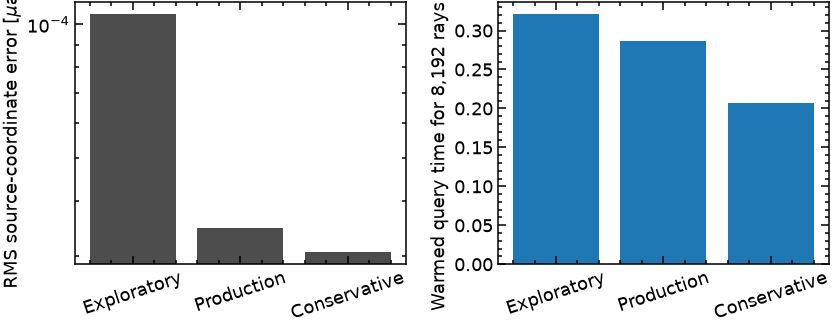

In [4]:
query_count = 8_192 if use_cuda else 1_024
generator = torch.Generator(device="cpu").manual_seed(83)
xmin, xmax, ymin, ymax = lens_region.bounds_uas
query_x = xmin + (xmax - xmin) * torch.rand(query_count, generator=generator)
query_y = ymin + (ymax - ymin) * torch.rand(query_count, generator=generator)
query_x = query_x.to(simulation.runtime.device, simulation.runtime.dtype)
query_y = query_y.to(simulation.runtime.device, simulation.runtime.dtype)

reference_x, reference_y, direct_diagnostics = simulation.raytrace_direct(query_x, query_y)
simulation.runtime.synchronize()

variants = {
    "Exploratory": exploratory_far_field,
    "Production": production_far_field,
    "Conservative": conservative_far_field,
}
rows = []
for name, config in variants.items():
    # Warm the fixed shape once so compilation is not charged to one variant.
    TaylorFarFieldApproximation(simulation, lens_region, config)
    simulation.runtime.synchronize()
    started = perf_counter()
    approximation = TaylorFarFieldApproximation(simulation, lens_region, config)
    simulation.runtime.synchronize()
    build_seconds = perf_counter() - started

    # One unreported query initializes any backend-specific query kernel.
    approximation.raytrace(query_x, query_y)
    simulation.runtime.synchronize()
    started = perf_counter()
    mapped_x, mapped_y = approximation.raytrace(query_x, query_y)
    simulation.runtime.synchronize()
    query_seconds = perf_counter() - started

    radial_error = torch.sqrt((mapped_x - reference_x).square() + (mapped_y - reference_y).square())
    rows.append({
        "name": name,
        "rms_uas": float(torch.sqrt(torch.mean(radial_error.square())).cpu()),
        "p99_uas": float(torch.quantile(radial_error, 0.99).cpu()),
        "build_s": build_seconds,
        "query_ms": 1_000.0 * query_seconds,
        "max_local": approximation.diagnostics.maximum_local_stars,
        "backend": approximation.last_query_backend,
    })

for row in rows:
    print(
        f"{row['name']:12s} RMS={row['rms_uas']:.4g} uas  "
        f"p99={row['p99_uas']:.4g} uas  warmed-build={row['build_s']:.3f} s  "
        f"query={row['query_ms']:.3f} ms  max-local={row['max_local']}  "
        f"backend={row['backend']}"
    )

figure, axes = plt.subplots(1, 2, figsize=(8.7, 3.6))
names = [row["name"] for row in rows]
axes[0].bar(names, [row["rms_uas"] for row in rows], color="0.30")
axes[0].set_yscale("log")
axes[0].set_ylabel(r"RMS source-coordinate error [$\mu$as]")
axes[1].bar(names, [row["query_ms"] for row in rows], color="tab:blue")
axes[1].set_ylabel(f"Warmed query time for {query_count:,} rays [ms]")
for axis in axes:
    axis.tick_params(axis="x", rotation=18)
    mcp.finish_axis(axis)
figure.tight_layout()
plt.show()

## Practical adjustment order

1. Begin with `production_ipm_config(...)`, which supplies the validated
   `16 × 16` parent partition, `8 × 8` node lattice, one-cell exact radius,
   order-four query polynomial, and order-ten center expansion.
2. Validate against `simulation.raytrace_direct` on representative query
   points and against a higher-quality map or light curve.
3. If rare near-star errors dominate, increase `exact_radius_cells` first.
   If error is spatially smooth within cells, increase
   `nodes_per_cell_axis` or `center_translation_order`.
4. Change `cells_per_axis` only with a joint build/query benchmark. More cells
   are not automatically faster because they trade coefficient work against
   exact local-star work.
5. Change `taylor_order` only as a dedicated method study. Order four is the
   production CUDA specialization; a higher mathematical order can be slower
   through a portable backend.
6. Recheck representative difficult macroimages after every change. Do not
   infer a universal tolerance from one stellar realization.

`production_dynamic_config()` controls temporal batching and conservative
scout reuse. Those settings do not alter this spatial approximation. In
particular, the production far field is reconstructed at every map epoch; no
temporal coefficient stride is used.